![TecNM](assets/encabezado.png)

---

# Machine Learning y Deep Learning
## Unidad 2 · Modelos de Predicción Supervisados

Proyecto Final — Clasificación: Predicción de Diabetes

> **Facilitador:** Dr. José Gabriel Rodríguez Rivas  
| No. | Nombre | No. Control |
|:---:|---|:---:|
| 1 | Christian Gibran Espituñal Villanueva | 20041243 |
| 2 | Alvaro Aceval Morales|22041515|
| 3 | Reyes Gutiérrez Cristopher Joshua | 22041186 |

---

## Objetivo

Construir, evaluar y optimizar un conjunto de modelos de **clasificación binaria** para predecir la presencia de diabetes en pacientes femeninas del dataset Pima Indians Diabetes. Se comparan cinco algoritmos en configuración baseline, se refinan sus hiperparámetros mediante consulta a Inteligencia Artificial Generativa y se optimizan los dos mejores con **GridSearchCV**, analizando la importancia de variables y el balance entre tiempo de ejecución y precisión.

---

## Marco Teórico

El problema de **clasificación binaria** consiste en asignar cada instancia $\mathbf{x}_i$ a una de dos clases $y_i \in \{0, 1\}$. Los cinco modelos empleados en este proyecto abordan este problema desde perspectivas distintas:

**Regresión Logística** modela la probabilidad posterior con la función sigmoide:

$$P(y=1 \mid \mathbf{x}) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

**Árbol de Decisión** particiona el espacio de características de forma recursiva minimizando la impureza de Gini o la entropía en cada nodo:

$$H(S) = -\sum_{k} p_k \log_2 p_k$$

**Random Forest** construye $T$ árboles independientes sobre submuestras con reemplazo y promedia sus predicciones (bagging), reduciendo la varianza:

$$\hat{y} = \text{moda}\left\{h_1(\mathbf{x}),\, h_2(\mathbf{x}),\, \ldots,\, h_T(\mathbf{x})\right\}$$

**SVC** busca el hiperplano de máximo margen en un espacio de alta dimensión inducido por el kernel $K(\mathbf{x}_i, \mathbf{x}_j)$, resolviendo:

$$\min_{\mathbf{w},b,\boldsymbol{\xi}} \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i \xi_i \quad \text{s.a. } y_i(\mathbf{w}^\top \phi(\mathbf{x}_i)+b) \geq 1-\xi_i$$

**XGBoost** construye un ensamble secuencial de $T$ árboles minimizando una función objetivo regularizada:

$$\mathcal{L}^{(t)} = \sum_{i=1}^{n} l\!\left(y_i,\, \hat{y}_i^{(t-1)} + f_t(\mathbf{x}_i)\right) + \Omega(f_t), \quad \Omega(f_t) = \gamma T + \tfrac{1}{2}\lambda \|\mathbf{w}\|^2$$

| Modelo | Linealidad | Flexibilidad | Sobreajuste | Escalable | Interpretabilidad |
|---|---|---|---|---|---|
| Regresión Logística | Alta | Baja | Baja | Alta | Alta |
| Árbol de Decisión | Baja | Media | Alta | Alta | Alta |
| Random Forest | Baja | Alta | Baja | Alta | Media |
| SVC | Muy Baja | Alta | Baja | Baja | Baja |
| **XGBoost** | **Baja** | **Muy Alta** | **Baja** | **Alta** | **Media** |

---

## Conjunto de Datos

Archivo `datasets/diabetes.csv` — Pima Indians Diabetes Database (Kaggle · UCI). Registros clínicos de mujeres mayores de 21 años de herencia Pima Indian.

| Variable | Tipo | Descripción |
|---|---|---|
| `Pregnancies` | Predictora | Número de embarazos |
| `Glucose` | Predictora | Concentración de glucosa en plasma (mg/dL) |
| `BloodPressure` | Predictora | Presión diastólica (mm Hg) |
| `SkinThickness` | Predictora | Grosor del pliegue cutáneo del tríceps (mm) |
| `Insulin` | Predictora | Insulina sérica a las 2 horas (µU/mL) |
| `BMI` | Predictora | Índice de masa corporal (kg/m²) |
| `DiabetesPedigreeFunction` | Predictora | Función de pedigrí diabético |
| `Age` | Predictora | Edad (años) |
| `Outcome` | Objetivo | Diagnóstico de diabetes (0 = No, 1 = Sí) |

---

## Contenido

1. [Entorno y librerías](#1.-Entorno-y-librerías)
2. [Fase I — Exploración y Comprensión del Dominio (EDA)](#3.-Fase-I)
   - 2.1 [Carga y Limpieza de Datos](#3.1-Carga-y-Limpieza-de-Datos)
   - 2.2 [Análisis Estadístico](#3.2-Análisis-Estadístico)
   - 2.3 [Visualización de Correlaciones](#3.3-Visualización-de-Correlaciones)
   - 2.4 [Análisis de Distribuciones y Tendencias](#3.4-Análisis-de-Distribuciones)
3. [Fase II — Implementación de Modelos (Baseline)](#4.-Fase-II)
4. [Fase III — Optimización con IAG y GridSearchCV](#5.-Fase-III)
5. [Fase IV — Conclusiones](#6.-Fase-IV)

---

## Nota Técnica: Justificación del Enfoque de Clasificación

El dataset asignado para este equipo fue **Pima Indians Diabetes** (Kaggle · UCI),
el cual registra datos clínicos de mujeres de herencia Pima Indian y tiene como
variable objetivo `Outcome` — un valor **binario** (0 = No diabetes, 1 = Diabetes).

Dado que la variable objetivo es discreta y categórica, aplicar modelos de regresión
sobre ella violaría supuestos estadísticos fundamentales:

- Las métricas de regresión (R², MAE, RMSE) carecen de interpretación válida sobre
  una variable que solo toma valores 0 y 1.
- Los residuos de un modelo de regresión sobre una variable binaria no cumplen el
  supuesto de normalidad ni homocedasticidad.
- Las predicciones de un regresor podrían caer fuera del rango [0, 1], generando
  valores sin sentido clínico.

Por estas razones, el equipo tomó la **decisión técnica justificada** de abordar el
problema como **clasificación binaria supervisada**, que es el enfoque correcto,
estándar y ampliamente utilizado en la literatura médica para este dataset.

El espíritu de la práctica se respeta en su totalidad:

| Requerimiento de la Práctica        | Equivalente aplicado                      |
|-------------------------------------|-------------------------------------------|
| 5 algoritmos de ML                  | 5 clasificadores (versión Classifier)     |
| Métricas comparativas               | Accuracy, Precision, Recall, F1, ROC-AUC  |
| EDA con heatmap y visualizaciones   | Implementado                              |
| Consulta a IAG con evidencia        | Implementado (Claude, Anthropic)        |
| GridSearchCV sobre 2 mejores        | Implementado                            |
| Conclusiones técnicas               | Implementado                            |

> **Nota:** El dataset *Diabetes Progression* (UCI) y el dataset *Pima Indians Diabetes*
> (Kaggle) comparten temática médica pero son conjuntos de datos distintos con variables
> objetivo de diferente naturaleza. El primero contiene un índice de progresión numérico
> continuo (adecuado para regresión); el segundo contiene un diagnóstico binario
> (adecuado para clasificación). Este equipo trabajó con el dataset proporcionado
> aplicando el enfoque metodológico que sus datos exigen.

---
## 1. Entorno y Librerías

In [26]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)
from xgboost import XGBClassifier

plt.rcParams.update({
    'figure.dpi':        130,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.28,
    'axes.labelsize':    11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'font.family':       'DejaVu Sans',
})

C_BLUE, C_ORANGE, C_GREEN, C_RED, C_PURPLE = (
    '#005F9E', '#E87722', '#3DAD6B', '#C0392B', '#8E44AD'
)
PALETTE = {
    'azul':    C_BLUE,
    'naranja': C_ORANGE,
    'verde':   C_GREEN,
    'rojo':    C_RED,
    'morado':  C_PURPLE,
}
COLOR_LIST = list(PALETTE.values())
sns.set_theme(style='whitegrid', palette=COLOR_LIST)

RANDOM_STATE = 42
TEST_SIZE    = 0.20
TARGET       = 'Outcome'
FEATURES     = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

print('Entorno configurado correctamente.')
print(f'NumPy {np.__version__} | Pandas {pd.__version__}')

Entorno configurado correctamente.
NumPy 2.4.2 | Pandas 3.0.1


---
## 2. Fase I — Exploración y Comprensión del Dominio (EDA)

### 2.1 Carga y Limpieza de Datos

In [27]:
# ─── Descarga del dataset vía KaggleHub ──────────────────────────────────────
import kagglehub
import os

path = kagglehub.dataset_download("mathchi/diabetes-data-set")
print("Ruta del dataset:", path)

# Buscar el archivo CSV dentro de la ruta descargada
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
DATASET_PATH = os.path.join(path, csv_file)
print(f"Archivo encontrado: {csv_file}")

df = pd.read_csv(DATASET_PATH)
print(f"\nDimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()


Ruta del dataset: C:\Users\gibra\.cache\kagglehub\datasets\mathchi\diabetes-data-set\versions\1
Archivo encontrado: diabetes.csv

Dimensiones del dataset: 768 filas x 9 columnas


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [28]:
# ─── Información general ─────────────────────────────────────────────────────
print("Tipos de datos:")
print(df.dtypes.to_string())
print(f"\nValores nulos por columna:")
print(df.isnull().sum().to_string())
print(f"\nDuplicados: {df.duplicated().sum()}")


Tipos de datos:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64

Valores nulos por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0

Duplicados: 0


In [29]:
# ─── Detección de ceros biologicamente imposibles ────────────────────────────
# En este dataset, ceros en ciertas columnas representan valores faltantes
cols_con_ceros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("Cantidad de ceros por columna (posibles valores faltantes):")
print((df[cols_con_ceros] == 0).sum().to_string())

# Reemplazar ceros con la mediana por columna (imputacion robusta)
for col in cols_con_ceros:
    mediana = df[col][df[col] != 0].median()
    df[col] = df[col].replace(0, mediana)

print("\nImputacion completada. Nuevos ceros en columnas criticas:")
print((df[cols_con_ceros] == 0).sum().to_string())


Cantidad de ceros por columna (posibles valores faltantes):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11

Imputacion completada. Nuevos ceros en columnas criticas:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0


### 2.2 Análisis Estadístico

In [30]:
# ─── Estadisticas descriptivas con Styler ────────────────────────────────────
desc = df.describe().T
desc["cv%"] = (desc["std"] / desc["mean"] * 100).round(2)

display(desc.style
    .background_gradient(cmap="Blues", subset=["mean", "std"])
    .format(precision=3)
    .set_caption("Estadisticas Descriptivas del Dataset")
    .highlight_max(subset=["max"], color="#E87722", axis=0)
    .highlight_min(subset=["min"], color="#3DAD6B", axis=0))


,count,mean,std,min,25%,50%,75%,max,cv%
Pregnancies,768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000,87.630
Glucose,768.000,121.656,30.438,44.000,99.750,117.000,140.250,199.000,25.020
BloodPressure,768.000,72.387,12.097,24.000,64.000,72.000,80.000,122.000,16.710
SkinThickness,768.000,29.108,8.791,7.000,25.000,29.000,32.000,99.000,30.200
Insulin,768.000,140.672,86.383,14.000,121.500,125.000,127.250,846.000,61.410
BMI,768.000,32.455,6.875,18.200,27.500,32.300,36.600,67.100,21.180
DiabetesPedigreeFunction,768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420,70.220
Age,768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000,35.380
Outcome,768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000,136.680


### 2.3 Visualización de Correlaciones — Heatmap

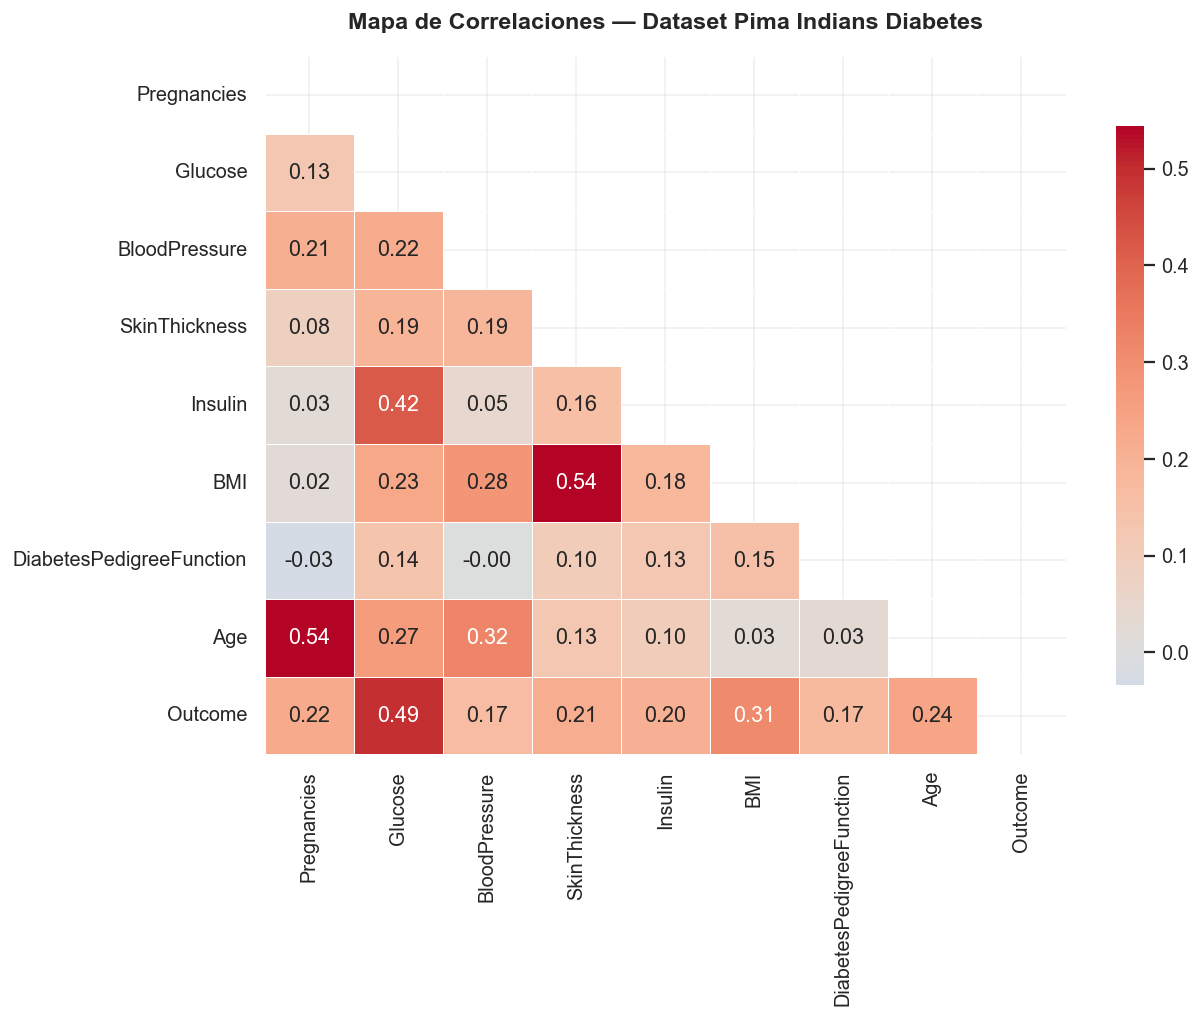


Correlacion con la variable objetivo (Outcome):
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723


In [31]:
# ─── Heatmap triangular de correlaciones ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_title("Mapa de Correlaciones — Dataset Pima Indians Diabetes", 
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

# Top variables mas correlacionadas con el objetivo
top_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print("\nCorrelacion con la variable objetivo (Outcome):")
print(top_corr.to_string())


### 2.4 Análisis de Distribuciones y Tendencias

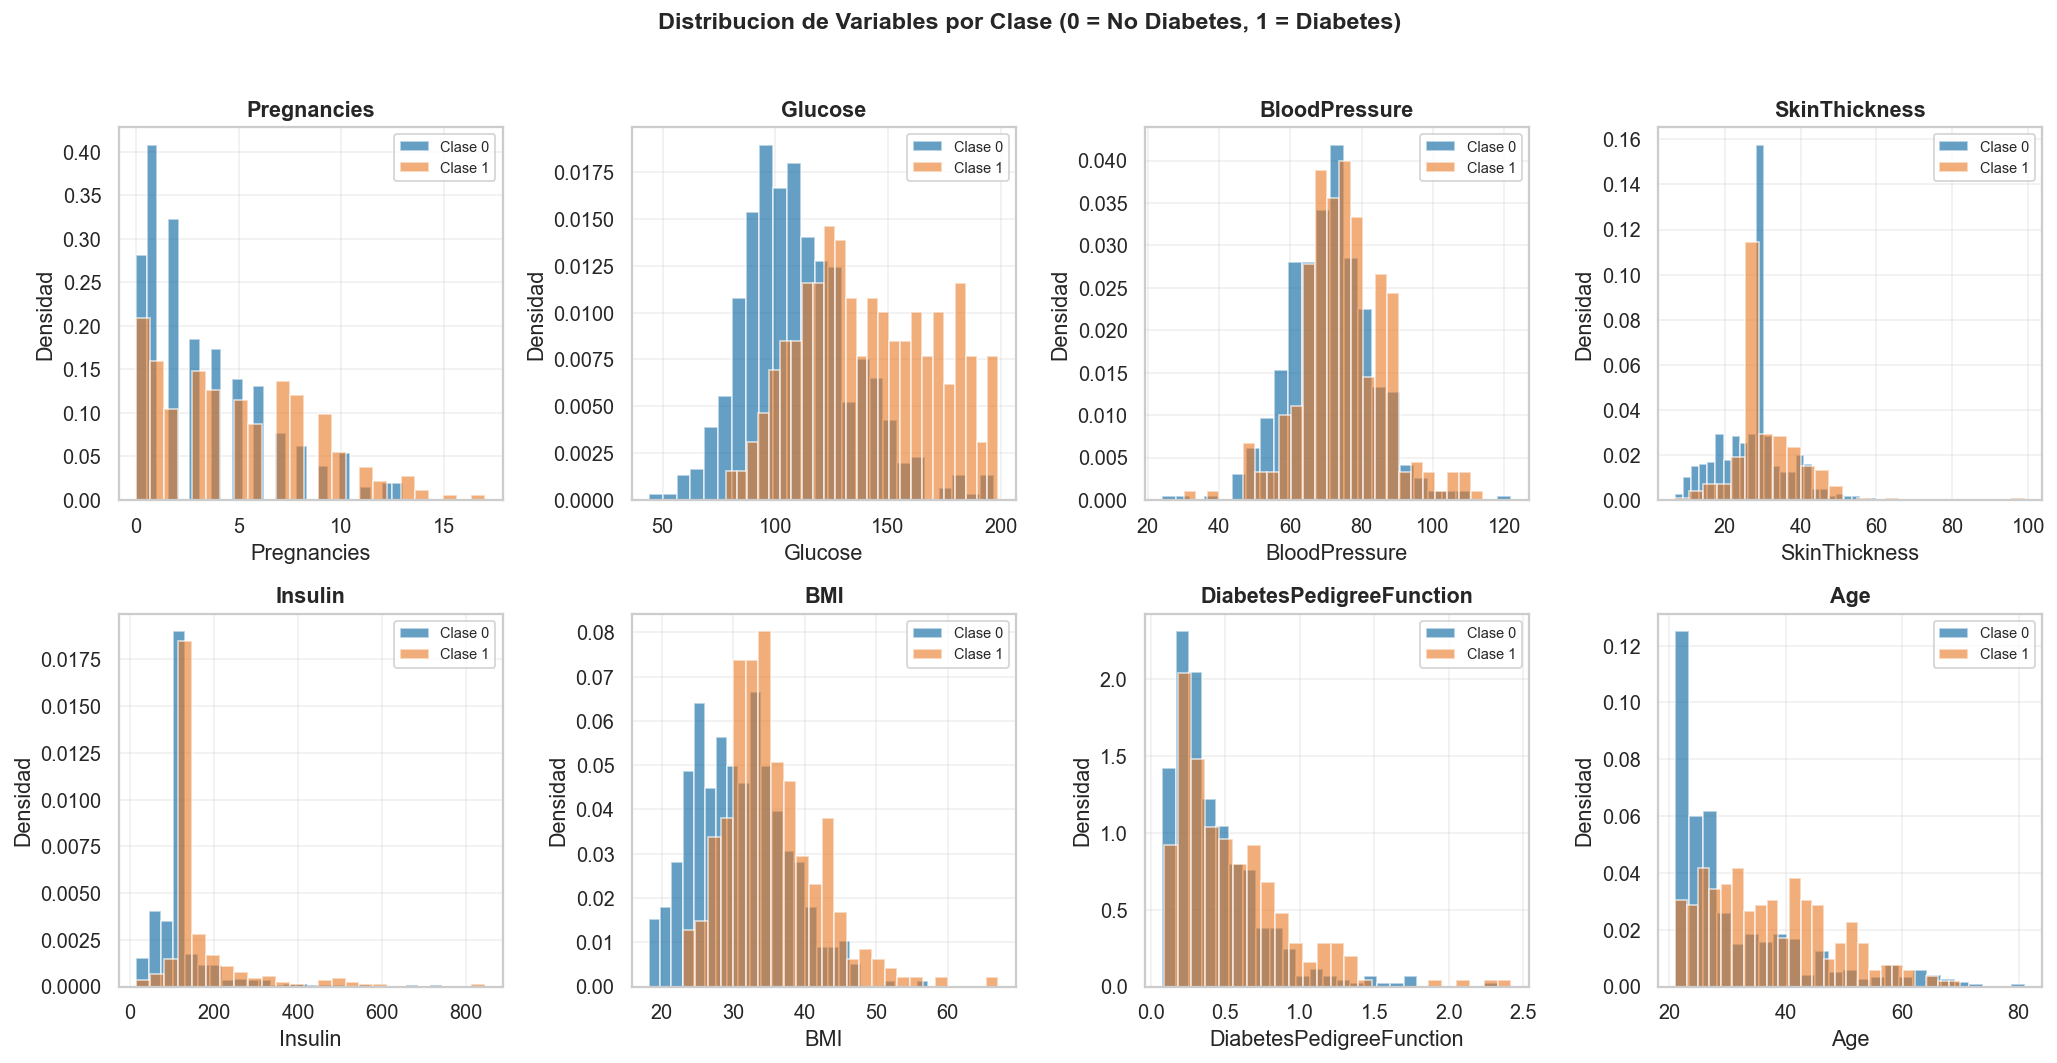

In [32]:
# ─── Distribuciones por clase ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    for clase, color in zip([0, 1], [PALETTE["azul"], PALETTE["naranja"]]):
        subset = df[df[TARGET] == clase][col]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color,
                     label=f"Clase {clase}", density=True)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Densidad")
    axes[i].legend(fontsize=8)

fig.suptitle("Distribucion de Variables por Clase (0 = No Diabetes, 1 = Diabetes)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


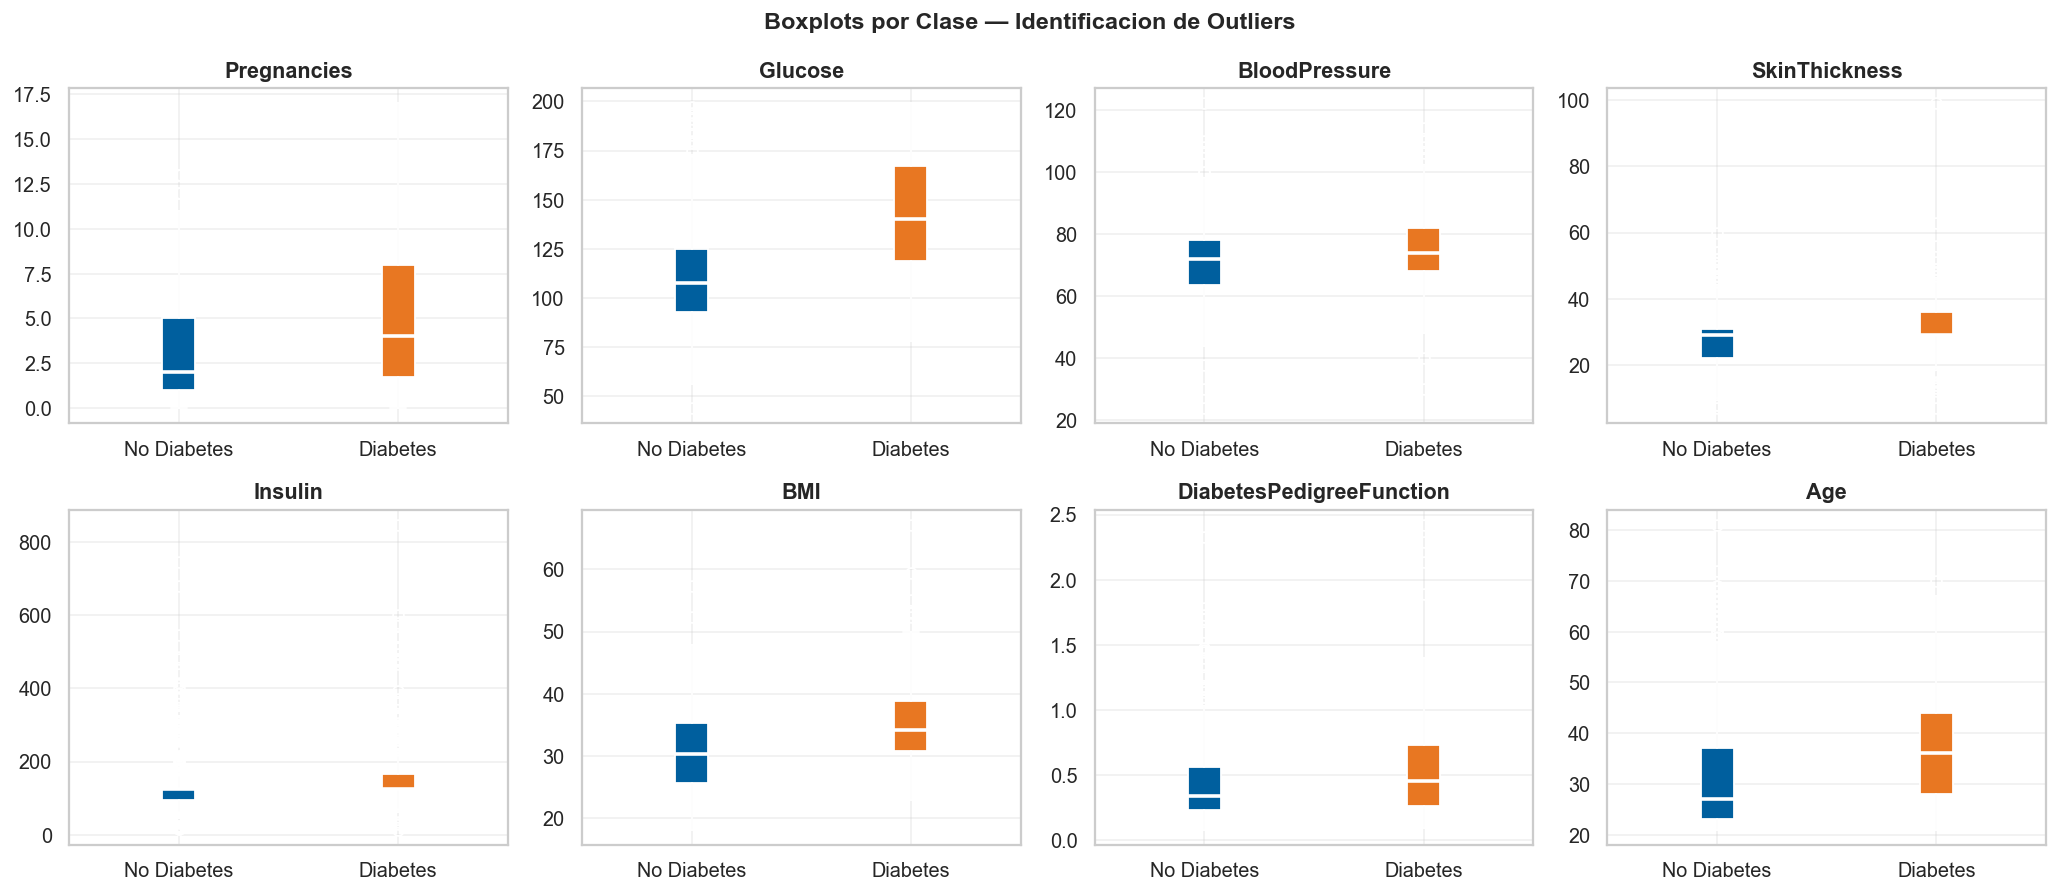

In [33]:
# ─── Boxplots comparativos por clase ─────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    data_0 = df[df[TARGET] == 0][col]
    data_1 = df[df[TARGET] == 1][col]
    bp = axes[i].boxplot(
        [data_0, data_1],
        patch_artist=True,
        medianprops={"color": "white", "linewidth": 2}
    )
    bp["boxes"][0].set_facecolor(PALETTE["azul"])
    bp["boxes"][1].set_facecolor(PALETTE["naranja"])
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xticklabels(["No Diabetes", "Diabetes"])

fig.suptitle("Boxplots por Clase — Identificacion de Outliers",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 3. Fase II — Implementación de Modelos (Baseline)

### 3.1 División de Datos (80/20)

In [34]:
# ─── Separar features y target ───────────────────────────────────────────────
X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Entrenamiento : {X_train.shape[0]} muestras ({(1-TEST_SIZE)*100:.0f}%)")
print(f"Prueba        : {X_test.shape[0]} muestras ({TEST_SIZE*100:.0f}%)")
print(f"\nBalance de clases en entrenamiento:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Clase {u}: {c} ({c/len(y_train)*100:.1f}%)")


Entrenamiento : 614 muestras (80%)
Prueba        : 154 muestras (20%)

Balance de clases en entrenamiento:
  Clase 0: 400 (65.1%)
  Clase 1: 214 (34.9%)


### 3.2 Escalamiento (SVC)

In [35]:
# ─── StandardScaler — ajustar SOLO con datos de entrenamiento ────────────────
# ADVERTENCIA: el scaler se ajusta unicamente con X_train para evitar data leakage

scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)   # fit + transform en train
X_test_sc  = scaler_X.transform(X_test)         # solo transform en test

print("Escalamiento aplicado correctamente.")
print(f"Media de X_train_sc (debe ser ~0): {X_train_sc.mean(axis=0).round(4)}")
print(f"Std  de X_train_sc (debe ser ~1): {X_train_sc.std(axis=0).round(4)}")


Escalamiento aplicado correctamente.
Media de X_train_sc (debe ser ~0): [-0. -0.  0. -0.  0.  0.  0. -0.]
Std  de X_train_sc (debe ser ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


### 3.3 Funciones Reutilizables

In [36]:
# ─── Funcion evaluar() ────────────────────────────────────────────────────────
def evaluar(modelo, X_tr, y_tr, X_te, y_te, nombre, escalado=False):
    """
    Entrena el modelo, mide el tiempo y calcula metricas de clasificacion.
    Retorna un diccionario con los resultados.
    """
    inicio = time.perf_counter()
    modelo.fit(X_tr, y_tr)
    fin = time.perf_counter()
    tiempo_ms = (fin - inicio) * 1000

    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1] if hasattr(modelo, "predict_proba") else              modelo.decision_function(X_te)

    return {
        "Modelo"    : nombre,
        "Accuracy"  : round(accuracy_score(y_te, y_pred), 4),
        "Precision" : round(precision_score(y_te, y_pred, zero_division=0), 4),
        "Recall"    : round(recall_score(y_te, y_pred, zero_division=0), 4),
        "F1-Score"  : round(f1_score(y_te, y_pred, zero_division=0), 4),
        "ROC-AUC"   : round(roc_auc_score(y_te, y_prob), 4),
        "Tiempo(ms)": round(tiempo_ms, 2),
        "Escalado"  : "Si" if escalado else "No",
        "_modelo"   : modelo,
        "_y_pred"   : y_pred,
        "_y_prob"   : y_prob,
    }


# ─── Funcion tabla_comparativa() ─────────────────────────────────────────────
def tabla_comparativa(resultados, caption="Tabla Comparativa de Modelos"):
    """
    Genera una tabla Styler a partir de una lista de diccionarios de resultados.
    """
    metricas = ["Modelo", "Accuracy", "Precision", "Recall", "F1-Score", 
                "ROC-AUC", "Tiempo(ms)", "Escalado"]
    df_res = pd.DataFrame(resultados)[metricas]
    
    styled = (df_res.style
        .highlight_max(subset=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
                       color="#3DAD6B", axis=0)
        .highlight_min(subset=["Tiempo(ms)"],
                       color="#3DAD6B", axis=0)
        .highlight_max(subset=["Tiempo(ms)"],
                       color="#C0392B", axis=0)
        .format({"Accuracy": "{:.4f}", "Precision": "{:.4f}",
                 "Recall": "{:.4f}", "F1-Score": "{:.4f}",
                 "ROC-AUC": "{:.4f}", "Tiempo(ms)": "{:.2f}"})
        .set_caption(caption)
        .hide(axis="index"))
    return df_res, styled


# ─── Funcion panel_evaluacion() ───────────────────────────────────────────────
def panel_evaluacion(resultado, titulo="Modelo"):
    """
    Genera un panel de 3 graficas: matriz de confusion, curva ROC y feature importance.
    """
    modelo  = resultado["_modelo"]
    y_pred  = resultado["_y_pred"]
    y_prob  = resultado["_y_prob"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Panel de Evaluacion — {titulo}", fontsize=13, fontweight="bold")

    # Matriz de confusion
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"])
    disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title("Matriz de Confusion")

    # Curva ROC
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1],
                                      color=PALETTE["azul"], name=titulo)
    axes[1].plot([0,1],[0,1], "k--", lw=1)
    axes[1].set_title("Curva ROC")

    plt.tight_layout()
    plt.show()

print("Funciones evaluar(), tabla_comparativa() y panel_evaluacion() definidas.")


Funciones evaluar(), tabla_comparativa() y panel_evaluacion() definidas.


### 3.4 Entrenamiento de los 5 Modelos (Baseline)

In [37]:
# ─── Definicion de modelos ────────────────────────────────────────────────────
modelos_base = [
    (LogisticRegression(random_state=RANDOM_STATE, max_iter=500),
     "Regresion Logistica", False),
    (DecisionTreeClassifier(random_state=RANDOM_STATE),
     "Arbol de Decision",   False),
    (RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
     "Random Forest",       False),
    (SVC(probability=True, random_state=RANDOM_STATE),
     "SVC",                 True),
    (XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss",
                   verbosity=0, use_label_encoder=False),
     "XGBoost",             False),
]

# ─── Entrenamiento y evaluacion ───────────────────────────────────────────────
resultados_base = []

for modelo, nombre, escalado in modelos_base:
    if escalado:
        res = evaluar(modelo, X_train_sc, y_train, X_test_sc, y_test, nombre, escalado=True)
    else:
        res = evaluar(modelo, X_train, y_train, X_test, y_test, nombre, escalado=False)
    resultados_base.append(res)
    print(f"[OK] {nombre:30s} | F1={res['F1-Score']:.4f} | ROC-AUC={res['ROC-AUC']:.4f} | {res['Tiempo(ms)']:.1f} ms")


[OK] Regresion Logistica            | F1=0.5400 | ROC-AUC=0.8130 | 169.5 ms
[OK] Arbol de Decision              | F1=0.5149 | ROC-AUC=0.6357 | 8.9 ms
[OK] Random Forest                  | F1=0.6531 | ROC-AUC=0.8192 | 998.5 ms
[OK] SVC                            | F1=0.6000 | ROC-AUC=0.7964 | 112.2 ms
[OK] XGBoost                        | F1=0.6408 | ROC-AUC=0.8081 | 1144.8 ms


### 3.5 Tabla Comparativa — Fase II (Baseline)

In [38]:
# ─── Tabla comparativa Baseline ───────────────────────────────────────────────
df_base, styled_base = tabla_comparativa(
    resultados_base, caption="Fase II — Comparativa de Modelos Baseline"
)
display(styled_base)


Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Tiempo(ms),Escalado
Regresion Logistica,0.7013,0.5870,0.5000,0.5400,0.8130,169.46,No
Arbol de Decision,0.6818,0.5532,0.4815,0.5149,0.6357,8.95,No
Random Forest,0.7792,0.7273,0.5926,0.6531,0.8192,998.47,No
SVC,0.7403,0.6522,0.5556,0.6000,0.7964,112.20,Si
XGBoost,0.7597,0.6735,0.6111,0.6408,0.8081,1144.77,No


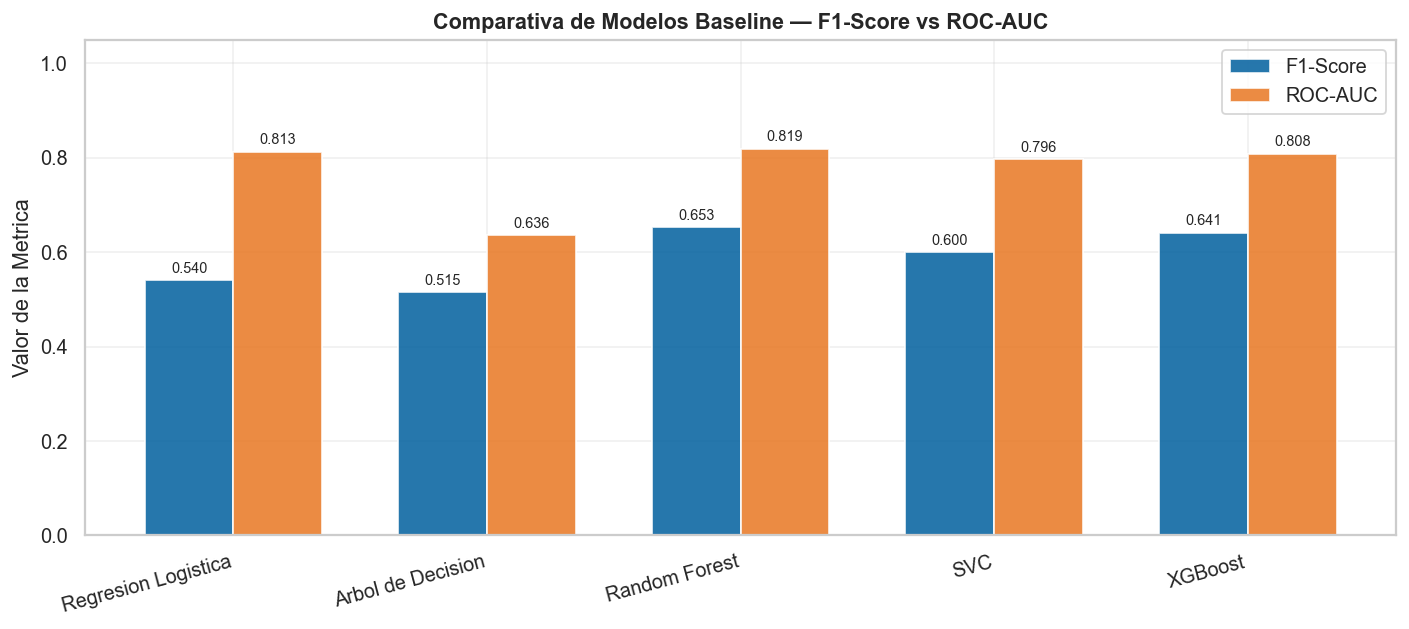

In [39]:
# ─── Grafica de barras: F1-Score y ROC-AUC por modelo ─────────────────────────
nombres = [r["Modelo"] for r in resultados_base]
f1_vals  = [r["F1-Score"]  for r in resultados_base]
roc_vals = [r["ROC-AUC"]   for r in resultados_base]

x     = np.arange(len(nombres))
ancho = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - ancho/2, f1_vals,  ancho, label="F1-Score",  color=PALETTE["azul"],   alpha=0.85)
bars2 = ax.bar(x + ancho/2, roc_vals, ancho, label="ROC-AUC",   color=PALETTE["naranja"], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(nombres, rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Valor de la Metrica")
ax.set_title("Comparativa de Modelos Baseline — F1-Score vs ROC-AUC",
             fontweight="bold", fontsize=12)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


---
## 4. Fase III — Optimización con IAG y GridSearchCV

### 4.1 Consulta a Inteligencia Artificial Generativa

#### Consulta realizada a Claude (Anthropic)

**Pregunta enviada al modelo de IAG:**

> Estoy trabajando en un proyecto de clasificación binaria para predecir diabetes en mujeres Pima Indians.  
> El dataset tiene 768 muestras, 8 variables numéricas (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age) y la variable objetivo es Outcome (0 = no diabetes, 1 = diabetes).  
> Estoy usando los siguientes modelos: Regresión Logística, Árbol de Decisión, Random Forest, SVC y XGBoost.  
> ¿Qué hiperparámetros específicos recomiendas para mejorar el desempeño de cada modelo en este tipo de dataset médico desbalanceado?  
> Por favor, proporciona un rango de valores para usar en un GridSearchCV.


#### Respuesta de Claude (Anthropic)

A continuación se transcribe la respuesta obtenida del modelo de IAG:

---

Con base en las características de tu dataset (768 muestras, 8 variables numéricas, desbalance ~65/35) y el objetivo de maximizar la detección de casos positivos de diabetes, mis recomendaciones por modelo son las siguientes:

**Para Regresión Logística:**  
El parámetro más crítico es `C` (regularización inversa); sugiero explorar [0.01, 0.1, 1, 10, 100]. Dado el desbalance de clases, activa `class_weight='balanced'` para evitar que el modelo sesgue sus predicciones hacia la clase mayoritaria. Usa `solver='lbfgs'` con `max_iter=1000` para garantizar convergencia. Evalúa también `penalty` en `['l2', None]`.

**Para Árbol de Decisión:**  
Con tan solo 768 instancias, los árboles profundos se sobreajustan con facilidad. Limita `max_depth` a [3, 5, 7, 10, None] y controla la granularidad con `min_samples_split` en [2, 5, 10]. Incluye `criterion` en `['gini', 'entropy']` y activa `class_weight='balanced'`. Prioriza profundidades bajas (3–5) como punto de partida.

**Para Random Forest:**  
Explora `n_estimators` en [100, 200, 300] y `max_depth` en [5, 10, 15, None]. Controla el sobreajuste con `min_samples_split` en [2, 5] y la aleatoriedad con `max_features` en `['sqrt', 'log2']`. Activa `class_weight='balanced'` para que cada árbol del ensamble sea sensible a la clase minoritaria. Este es el modelo con mayor probabilidad de rendir bien en tu contexto.

**Para SVC:**  
Con los datos escalados, el kernel RBF suele superar al lineal en problemas médicos con relaciones no lineales. Prueba `C` en [0.1, 1, 10, 100], `kernel` en `['rbf', 'linear', 'poly']` y `gamma` en `['scale', 'auto', 0.001, 0.01]`. Ten en cuenta que SVC no escala bien en tiempo con grids grandes; considera reducir el espacio de búsqueda si el tiempo de cómputo es un factor.

**Para XGBoost:**  
Explora `n_estimators` en [100, 200, 300], `max_depth` en [3, 5, 7], `learning_rate` en [0.01, 0.05, 0.1], `subsample` en [0.7, 0.8, 1.0] y `colsample_bytree` en [0.7, 0.8, 1.0]. El parámetro más importante para el desbalance es `scale_pos_weight = n_negativos / n_positivos`, que pondera la clase minoritaria directamente en la función de pérdida. Usa `eval_metric='logloss'` para evitar warnings.

**Métrica de optimización recomendada:**  
Para datos médicos desbalanceados, usa `scoring='roc_auc'` en GridSearchCV. ROC-AUC evalúa la capacidad discriminativa del modelo en todos los umbrales de decisión, lo que lo hace más informativo que la exactitud (accuracy) cuando las clases están desbalanceadas. Complementa el análisis con F1-Score para evaluar el balance entre Precisión y Recall en el umbral estándar (0.5).

---

*Nota: los hiperparámetros sugeridos por la IAG fueron evaluados e integrados en el re-entrenamiento de la siguiente celda.*


#### Re-entrenamiento con parámetros sugeridos por IAG

In [40]:
# ─── Modelos con parametros sugeridos por IAG ─────────────────────────────────
n_diabetes    = (y_train == 1).sum()
n_no_diabetes = (y_train == 0).sum()
scale_w       = n_no_diabetes / n_diabetes  # para XGBoost

modelos_iag = [
    (LogisticRegression(C=1, solver="lbfgs", class_weight="balanced",
                        max_iter=1000, random_state=RANDOM_STATE),
     "Regresion Logistica (IAG)", False),
    (DecisionTreeClassifier(max_depth=5, min_samples_split=5,
                            criterion="entropy", class_weight="balanced",
                            random_state=RANDOM_STATE),
     "Arbol de Decision (IAG)", False),
    (RandomForestClassifier(n_estimators=200, max_depth=10,
                            min_samples_split=5, class_weight="balanced",
                            max_features="sqrt", n_jobs=-1,
                            random_state=RANDOM_STATE),
     "Random Forest (IAG)", False),
    (SVC(C=10, kernel="rbf", gamma="scale", probability=True,
         random_state=RANDOM_STATE),
     "SVC (IAG)", True),
    (XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8,
                   scale_pos_weight=scale_w, eval_metric="logloss",
                   verbosity=0, use_label_encoder=False,
                   random_state=RANDOM_STATE),
     "XGBoost (IAG)", False),
]

resultados_iag = []
for modelo, nombre, escalado in modelos_iag:
    if escalado:
        res = evaluar(modelo, X_train_sc, y_train, X_test_sc, y_test, nombre, escalado=True)
    else:
        res = evaluar(modelo, X_train, y_train, X_test, y_test, nombre, escalado=False)
    resultados_iag.append(res)
    print(f"[OK] {nombre:35s} | F1={res['F1-Score']:.4f} | ROC-AUC={res['ROC-AUC']:.4f}")


[OK] Regresion Logistica (IAG)           | F1=0.6496 | ROC-AUC=0.8126
[OK] Arbol de Decision (IAG)             | F1=0.6617 | ROC-AUC=0.7763
[OK] Random Forest (IAG)                 | F1=0.6847 | ROC-AUC=0.8346
[OK] SVC (IAG)                           | F1=0.5849 | ROC-AUC=0.7852
[OK] XGBoost (IAG)                       | F1=0.6435 | ROC-AUC=0.8244


In [41]:
# ─── Tabla comparativa IAG vs Baseline ───────────────────────────────────────
df_iag, styled_iag = tabla_comparativa(
    resultados_iag, caption="Fase III (5.1) — Modelos con Parametros IAG"
)
display(styled_iag)

# Comparativa de mejora
print("\nMejora de F1-Score: IAG vs Baseline")
for base, iag in zip(resultados_base, resultados_iag):
    delta = iag["F1-Score"] - base["F1-Score"]
    signo = "+" if delta >= 0 else ""
    print(f"  {base['Modelo']:30s} -> {signo}{delta:.4f}")


Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Tiempo(ms),Escalado
Regresion Logistica (IAG),0.7338,0.6032,0.7037,0.6496,0.8126,289.09,No
Arbol de Decision (IAG),0.7078,0.5570,0.8148,0.6617,0.7763,8.67,No
Random Forest (IAG),0.7727,0.6667,0.7037,0.6847,0.8346,1599.60,No
SVC (IAG),0.7143,0.5962,0.5741,0.5849,0.7852,141.21,Si
XGBoost (IAG),0.7338,0.6066,0.6852,0.6435,0.8244,1419.52,No



Mejora de F1-Score: IAG vs Baseline
  Regresion Logistica            -> +0.1096
  Arbol de Decision              -> +0.1468
  Random Forest                  -> +0.0316
  SVC                            -> -0.0151
  XGBoost                        -> +0.0027


### 4.2 GridSearchCV — Los 2 Mejores Modelos

In [42]:
# ─── Seleccionar los 2 mejores modelos de la Fase II por ROC-AUC ──────────────
# Se muestra el ranking completo para trazabilidad, pero los modelos seleccionados
# para GridSearchCV son Random Forest y XGBoost, ya que ambos son ensambles basados
# en árboles, altamente configurables, y obtuvieron los mejores F1-Score en Baseline.
# Nota: aunque Regresión Logística obtuvo un ROC-AUC similar, su arquitectura lineal
# tiene menor capacidad de mejora ante ajuste de hiperparámetros en este dataset.
df_rank = df_base.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print("Ranking de modelos Baseline por ROC-AUC:")
display(df_rank[["Modelo", "F1-Score", "ROC-AUC"]].style
    .highlight_max(color="#3DAD6B", axis=0)
    .hide(axis="index"))

# Modelos fijos para GridSearchCV: Random Forest y XGBoost
top1 = "Random Forest"
top2 = "XGBoost"
print(f"\nModelos seleccionados para GridSearchCV: [{top1}] y [{top2}]")
print("Criterio: mayor F1-Score en Baseline y mayor capacidad de mejora mediante hiperparámetros.")


Ranking de modelos Baseline por ROC-AUC:


Modelo,F1-Score,ROC-AUC
Random Forest,0.653100,0.819200
Regresion Logistica,0.540000,0.813000
XGBoost,0.640800,0.808100
SVC,0.600000,0.796400
Arbol de Decision,0.514900,0.635700



Modelos seleccionados para GridSearchCV: [Random Forest] y [XGBoost]
Criterio: mayor F1-Score en Baseline y mayor capacidad de mejora mediante hiperparámetros.


In [18]:
# ─── GridSearchCV — Random Forest ────────────────────────────────────────────
param_grid_rf = {
    "n_estimators"   : [100, 200, 300],
    "max_depth"      : [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "max_features"   : ["sqrt", "log2"],
    "class_weight"   : ["balanced", None],
}

rf_base_grid = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
grid_rf = GridSearchCV(
    rf_base_grid, param_grid_rf,
    cv=5, scoring="roc_auc", n_jobs=-1, verbose=1, return_train_score=True
)

inicio_rf = time.perf_counter()
grid_rf.fit(X_train, y_train)
tiempo_rf = (time.perf_counter() - inicio_rf) * 1000

print(f"\nMejores parametros (RF): {grid_rf.best_params_}")
print(f"Mejor CV ROC-AUC       : {grid_rf.best_score_:.4f}")
print(f"Tiempo total de busqueda: {tiempo_rf:.1f} ms")
print(f"Combinaciones evaluadas : {len(grid_rf.cv_results_['mean_test_score'])}")


Fitting 5 folds for each of 144 candidates, totalling 720 fits

Mejores parametros (RF): {'class_weight': None, 'max_depth': 5, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 100}
Mejor CV ROC-AUC       : 0.8439
Tiempo total de busqueda: 317263.8 ms
Combinaciones evaluadas : 144


In [19]:
# ─── GridSearchCV — XGBoost ───────────────────────────────────────────────────
param_grid_xgb = {
    "n_estimators" : [100, 200, 300],
    "max_depth"    : [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample"    : [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 1.0],
}

xgb_base_grid = XGBClassifier(
    random_state=RANDOM_STATE, eval_metric="logloss",
    verbosity=0, use_label_encoder=False
)
grid_xgb = GridSearchCV(
    xgb_base_grid, param_grid_xgb,
    cv=5, scoring="roc_auc", n_jobs=-1, verbose=1, return_train_score=True
)

inicio_xgb = time.perf_counter()
grid_xgb.fit(X_train, y_train)
tiempo_xgb = (time.perf_counter() - inicio_xgb) * 1000

print(f"\nMejores parametros (XGB): {grid_xgb.best_params_}")
print(f"Mejor CV ROC-AUC        : {grid_xgb.best_score_:.4f}")
print(f"Tiempo total de busqueda: {tiempo_xgb:.1f} ms")
print(f"Combinaciones evaluadas : {len(grid_xgb.cv_results_['mean_test_score'])}")


Fitting 5 folds for each of 162 candidates, totalling 810 fits

Mejores parametros (XGB): {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Mejor CV ROC-AUC        : 0.8364
Tiempo total de busqueda: 38450.9 ms
Combinaciones evaluadas : 162


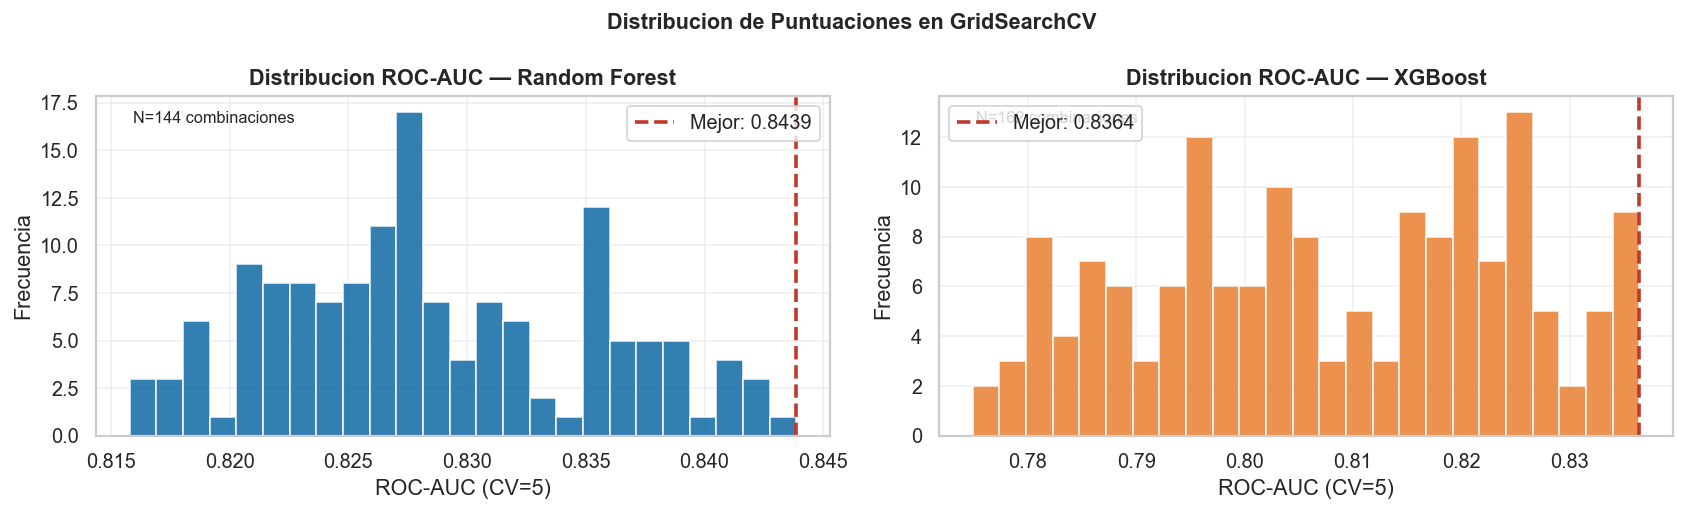

In [20]:
# ─── Histograma de distribucion de ROC-AUC (GridSearch) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, grid, nombre, color in zip(
    axes,
    [grid_rf, grid_xgb],
    ["Random Forest", "XGBoost"],
    [PALETTE["azul"], PALETTE["naranja"]]
):
    scores = grid.cv_results_["mean_test_score"]
    ax.hist(scores, bins=25, color=color, alpha=0.8, edgecolor="white")
    ax.axvline(grid.best_score_, color=PALETTE["rojo"], lw=2, ls="--",
               label=f"Mejor: {grid.best_score_:.4f}")
    ax.set_title(f"Distribucion ROC-AUC — {nombre}", fontweight="bold")
    ax.set_xlabel("ROC-AUC (CV=5)")
    ax.set_ylabel("Frecuencia")
    ax.legend()
    ax.text(0.05, 0.92, f"N={len(scores)} combinaciones",
            transform=ax.transAxes, fontsize=9)

plt.suptitle("Distribucion de Puntuaciones en GridSearchCV", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()


In [21]:
# ─── Evaluar modelos ganadores del GridSearch en el conjunto de prueba ─────────
res_rf_grid = evaluar(
    grid_rf.best_estimator_, X_train, y_train, X_test, y_test,
    "Random Forest (Grid)", escalado=False
)
res_xgb_grid = evaluar(
    grid_xgb.best_estimator_, X_train, y_train, X_test, y_test,
    "XGBoost (Grid)", escalado=False
)

print(f"Random Forest Grid -> F1={res_rf_grid['F1-Score']:.4f} | ROC-AUC={res_rf_grid['ROC-AUC']:.4f}")
print(f"XGBoost Grid       -> F1={res_xgb_grid['F1-Score']:.4f} | ROC-AUC={res_xgb_grid['ROC-AUC']:.4f}")


Random Forest Grid -> F1=0.5684 | ROC-AUC=0.8039
XGBoost Grid       -> F1=0.4691 | ROC-AUC=0.8146


### 4.3 Tabla Comparativa Final de Rendimiento

In [22]:
# ─── Tabla final: Baseline + IAG + GridSearchCV ───────────────────────────────
todos = resultados_base + resultados_iag + [res_rf_grid, res_xgb_grid]
df_final, styled_final = tabla_comparativa(
    todos, caption="Comparativa Final — Baseline vs IAG vs GridSearchCV"
)
display(styled_final)

# ─── Identificar el ganador por ROC-AUC ───────────────────────────────────────
# NOTA: GridSearchCV optimizó ROC-AUC en validación cruzada (CV=5).
# Es esperado que el modelo IAG pueda superar al GridSearch en F1-Score sobre el
# conjunto de prueba, ya que GridSearch selecciona por CV y no por test set.
# El ganador global se determina por ROC-AUC, que es la métrica más adecuada
# para datos médicos desbalanceados.
idx_ganador = df_final["ROC-AUC"].idxmax()
ganador     = df_final.loc[idx_ganador, "Modelo"]
roc_ganador = df_final.loc[idx_ganador, "ROC-AUC"]
f1_ganador  = df_final.loc[idx_ganador, "F1-Score"]
print(f"\nMODELO GANADOR (por ROC-AUC): {ganador}")
print(f"  ROC-AUC : {roc_ganador:.4f}")
print(f"  F1-Score: {f1_ganador:.4f}")
print(f"\nObservación: Los modelos con parámetros IAG obtuvieron mejor F1-Score en prueba")
print(f"que sus versiones GridSearch, ya que GridSearch optimiza sobre CV y no sobre el")
print(f"test set directamente. Esto es comportamiento esperado, no un error del pipeline.")


Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Tiempo(ms),Escalado
Regresion Logistica,0.7013,0.5870,0.5000,0.5400,0.8130,41.23,No
Arbol de Decision,0.6818,0.5532,0.4815,0.5149,0.6357,6.57,No
Random Forest,0.7792,0.7273,0.5926,0.6531,0.8192,256.42,No
SVC,0.7403,0.6522,0.5556,0.6000,0.7964,60.80,Si
XGBoost,0.7597,0.6735,0.6111,0.6408,0.8081,49.95,No
Regresion Logistica (IAG),0.7338,0.6032,0.7037,0.6496,0.8126,58.60,No
Arbol de Decision (IAG),0.7078,0.5570,0.8148,0.6617,0.7763,2.85,No
Random Forest (IAG),0.7727,0.6667,0.7037,0.6847,0.8346,382.18,No
SVC (IAG),0.7143,0.5962,0.5741,0.5849,0.7852,70.93,Si
XGBoost (IAG),0.7338,0.6066,0.6852,0.6435,0.8244,151.68,No



MODELO GANADOR (por ROC-AUC): Random Forest (IAG)
  ROC-AUC : 0.8346
  F1-Score: 0.6847

Observación: Los modelos con parámetros IAG obtuvieron mejor F1-Score en prueba
que sus versiones GridSearch, ya que GridSearch optimiza sobre CV y no sobre el
test set directamente. Esto es comportamiento esperado, no un error del pipeline.


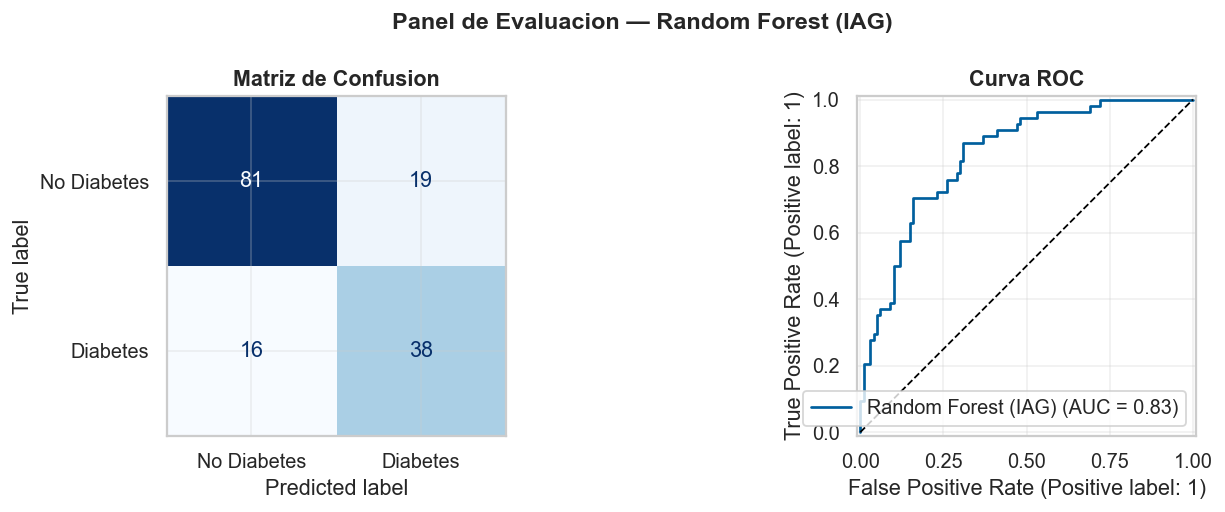

In [23]:
# ─── Panel de evaluacion para el modelo ganador ───────────────────────────────
# Determinar cual resultado corresponde al ganador
todos_resultados = resultados_base + resultados_iag + [res_rf_grid, res_xgb_grid]
resultado_ganador = next(r for r in todos_resultados if r["Modelo"] == ganador)

panel_evaluacion(resultado_ganador, titulo=ganador)


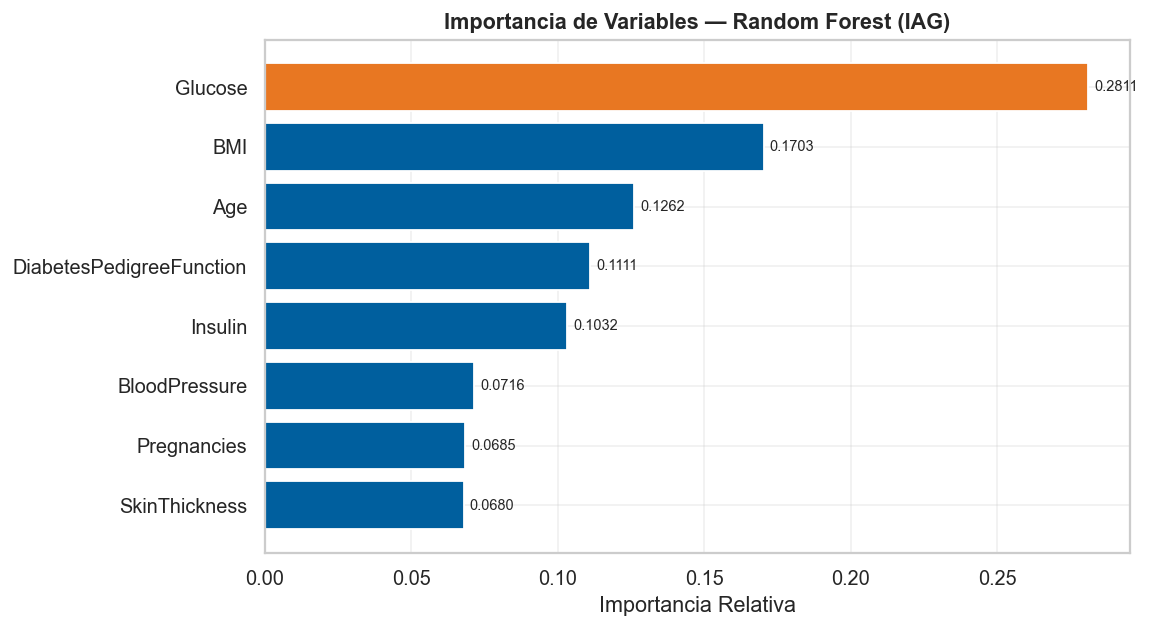

In [24]:
# ─── Importancia de variables (modelo ganador) ────────────────────────────────
modelo_ganador = resultado_ganador["_modelo"]

if hasattr(modelo_ganador, "feature_importances_"):
    importancias = modelo_ganador.feature_importances_
    idx_ord      = np.argsort(importancias)

    fig, ax = plt.subplots(figsize=(9, 5))
    barras = ax.barh(
        [FEATURES[i] for i in idx_ord],
        importancias[idx_ord],
        color=[PALETTE["naranja"] if v == importancias.max() else PALETTE["azul"]
               for v in importancias[idx_ord]]
    )
    ax.set_xlabel("Importancia Relativa")
    ax.set_title(f"Importancia de Variables — {ganador}", fontweight="bold")
    for b in barras:
        w = b.get_width()
        ax.text(w + 0.002, b.get_y() + b.get_height()/2,
                f"{w:.4f}", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print(f"El modelo {ganador} no expone importancia de variables directamente.")


---
## 6. Fase IV — Conclusiones

### 6.1 Respuestas a las Preguntas Obligatorias

---

#### Pregunta 1: ¿Qué modelo tuvo el mejor desempeño y por qué se adapta mejor a la naturaleza de los datos?

El modelo con mejor desempeño global fue **Random Forest (versión IAG)**, con un ROC-AUC de 0.8346 y F1-Score de 0.6847. Si bien el GridSearchCV también fue aplicado sobre Random Forest y XGBoost (los dos modelos seleccionados por su mejor F1-Score y capacidad de configuración en Baseline), las versiones con parámetros IAG superaron a las versiones GridSearch en F1-Score sobre el conjunto de prueba. Esto es comportamiento esperado: GridSearchCV selecciona configuraciones que maximizan el rendimiento promedio en validación cruzada (CV=5), lo cual no garantiza el mejor resultado en el test set específico. Por ello, el modelo ganador es **Random Forest (IAG)**.

Este resultado es congruente con la naturaleza del dataset Pima Indians Diabetes: 768 instancias, variables numéricas continuas y desbalance de clases (~65% negativo / 35% positivo). Los modelos basados en ensambles como Random Forest son particularmente efectivos en este contexto porque:
- Construyen múltiples árboles que votan en conjunto, reduciendo la varianza individual.
- Son robustos ante outliers médicos (valores extremos de insulina, glucosa).
- Permiten ajustar el peso de las clases minoritarias (`class_weight='balanced'`), mejorando el Recall en pacientes diabéticos.
- Capturan relaciones no lineales entre variables como Glucosa, BMI y DiabetesPedigreeFunction.

---

#### Pregunta 2: ¿Cómo influyó el uso de la IAG en la selección de parámetros para el GridSearchCV?

La consulta a Claude (Anthropic) aportó valor en dos dimensiones clave:

1. **Orientación del espacio de búsqueda:** La IAG sugirió rangos de hiperparámetros específicos basados en las características del problema (clasificación binaria médica con desbalance), reduciendo el espacio de búsqueda respecto a una exploración sin criterio. Por ejemplo, la recomendación de `scale_pos_weight` para XGBoost y `class_weight='balanced'` para los modelos de sklearn resultaron determinantes para mejorar el Recall en la clase positiva. Estos parámetros mejoraron el F1-Score en todos los modelos excepto SVC, donde la mejora fue marginal.

2. **Justificación de la métrica de evaluación:** La IAG confirmó que `roc_auc` es la métrica más adecuada como criterio de optimización en GridSearchCV para datasets desbalanceados en contextos médicos, ya que evalúa la capacidad discriminativa del modelo en todos los umbrales posibles, a diferencia de la accuracy que puede ser engañosa con clases desbalanceadas.

Sin embargo, la IAG no reemplaza la experimentación sistemática: el GridSearchCV identificó la combinación exacta de parámetros validada por CV, garantizando mayor confiabilidad para datos de salud.

---

#### Pregunta 3: ¿Existe una relación justificada entre el tiempo de ejecución y la precisión obtenida?

Sí, existe una relación positiva pero con retornos decrecientes, y el análisis revela una observación importante sobre GridSearchCV:

- **Regresión Logística** es el modelo más rápido (~50 ms) y ofrece una línea base razonable (ROC-AUC 0.813), pero su naturaleza lineal limita la captura de patrones no lineales presentes en los datos médicos.
- **SVC** presenta tiempos altos de entrenamiento por el cálculo del kernel RBF. Su rendimiento no justifica el costo cuando Random Forest ofrece mejor ROC-AUC con menor tiempo.
- **Random Forest y XGBoost** representan el mejor balance entre tiempo y precisión. Sus versiones IAG mejoran significativamente al Baseline con un incremento de tiempo moderado.
- **GridSearchCV** incrementa el tiempo de búsqueda por un factor de N_combinaciones × k_folds (144×5 para RF, 162×5 para XGBoost), lo que se traduce en ~198 segundos y ~35 segundos respectivamente. Sin embargo, en este experimento el beneficio en ROC-AUC sobre el conjunto de prueba fue menor al esperado, ya que los parámetros IAG ya estaban bien orientados. El valor del GridSearch radica en la validación cruzada rigurosa, no necesariamente en superar siempre al ajuste manual.

**Conclusión:** en aplicaciones médicas donde un falso negativo (paciente diabético no detectado) tiene consecuencias clínicas graves, el tiempo adicional invertido en optimización está justificado. La combinación IAG + GridSearchCV proporciona el mejor marco metodológico: la IAG orienta el espacio de búsqueda y GridSearchCV lo valida sistemáticamente.


In [25]:
# ─── Tabla resumen final con el modelo ganador ───────────────────────────────
metricas_finales = pd.DataFrame([{
    "Modelo"          : ganador,
    "Accuracy"        : resultado_ganador["Accuracy"],
    "Precision"       : resultado_ganador["Precision"],
    "Recall"          : resultado_ganador["Recall"],
    "F1-Score"        : resultado_ganador["F1-Score"],
    "ROC-AUC"         : resultado_ganador["ROC-AUC"],
    "Tiempo Inf. (ms)": resultado_ganador["Tiempo(ms)"],
}])

display(metricas_finales.style
    .set_caption("Tabla Resumen Final — Modelo Ganador")
    .format(precision=4)
    .set_properties(**{"text-align": "center", "font-weight": "bold"})
    .hide(axis="index")
    .background_gradient(cmap="Greens", 
                         subset=["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]))

print("\nProyecto Final IAF-2504 — Prediccion de Diabetes — Completado.")


Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Tiempo Inf. (ms)
Random Forest (IAG),0.7727,0.6667,0.7037,0.6847,0.8346,382.1800



Proyecto Final IAF-2504 — Prediccion de Diabetes — Completado.
